*Using Claude Code? Open it and paste this prompt:*

```
Clone https://github.com/SamDower/bluedot-tais-puzzle, cd into it, install dependencies with `pip install sentence-transformers torch`, and read the README to understand the puzzle. Then stop and wait for me — I want to drive the investigation myself, so don't run any analyses or propose which feature might be non-linear.
```

# BlueDot Technical AI Safety Puzzle #1

We trained a small classifier on short text inputs to predict eight binary features simultaneously, at over 95% accuracy on each:

- `number` — contains a digit or written-out number (3, seven, …)
- `question` — phrased as a question (ends in ?, or starts with who/what/why/…)
- `color` — contains a color word (red, blue, …)
- `food` — mentions food (pizza, apple, soup, …)
- `sentiment` — has positive vs. negative sentiment
- `country` — contains a country name (Japan, France, USA, …)
- `person` — contains a person's name (Alice, Mark, …)
- `body_part` — contains a body-part word (hand, eye, …)

After a particular layer L of this model, seven of these features are represented linearly, where a single direction in the activation space describes that feature. However, one feature is represented in a different way. Your job is to figure out which feature it is and how it is represented.

## The model architecture

The model consists of the `sentence-transformers/all-MiniLM-L6-v2` text encoder followed by a mean pool to get a single 384-dimensional representation of that input. This is then fed through a 5 layer MLP with ReLUs between the layers. The resulting 8 logits are then fed through individual sigmoid functions to recover the predicted probabilities for the 8 features.

![Model architecture](https://raw.githubusercontent.com/SamDower/bluedot-tais-puzzle/main/model_architecture.png)

The 8 probabilities don't need to sum to 1 because the eight features aren't mutually exclusive. The model was trained with per-feature binary cross-entropy across the eight outputs.

## What's in this repo

- `model.pt` — trained classifier state dict.
- `data/train.jsonl` — 7000 lines of `{"text": "...", "labels": [1, 1, 0, 0, 1, 0, 0, 1]}`. Labels indexed by `feature_names.json`.
- `data/test.jsonl` — 1500 lines, same format. Use this as a held-out test set.
- `feature_names.json` — the eight feature names, indexed 0–7.

## Setup (run this first)

Downloads the model and data. First run takes ~30s for the encoder download; re-runs are instant.

In [1]:
%pip install -q sentence-transformers torch


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## Task 1: Find the non-linear feature.

Identify which of the eight features is not represented linearly at the specified layer activations.

### Code to get you started

In [ ]:
import torch, torch.nn as nn
from sentence_transformers import SentenceTransformer

# --- 1. Define the MLP head  ---
class Head(nn.Module):
    def __init__(self):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(384, 64), nn.ReLU(),   # hidden 0
            nn.Linear(64, 64),  nn.ReLU(),   # hidden 1
            nn.Linear(64, 64),  nn.ReLU(),   # hidden 2  ← non-linear activation here (post-ReLU)
            nn.Linear(64, 64),  nn.ReLU(),   # hidden 3
            nn.Linear(64, 8),                # logits
        )
    def forward(self, x):
        return self.layers(x)

# --- 2. Load encoder (downloaded from HF) and head (local file) ---
enc = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2")
m = Head()
m.load_state_dict(torch.load("model.pt", map_location="cpu", weights_only=False))
m.eval()

# --- 3. Get predictions ---
texts = [
    "Alice loves the red car she bought in Japan for two hundred dollars.",
    "Did Sarah eat pizza with her hands in Italy?",
]

with torch.no_grad():
    embeddings = torch.from_numpy(
        enc.encode(texts, convert_to_numpy=True)   # (N, 384), mean-pooled
    )
    logits = m(embeddings)                          # (N, 8)
    probs  = torch.sigmoid(logits)                  # (N, 8) — independent per feature
    preds  = (probs > 0.5).int()                    # (N, 8) — binary predictions

# --- 4. Get activations at the right spot (post-ReLU of hidden 2) ---
# layers[0:6] = Linear, ReLU, Linear, ReLU, Linear, ReLU  → output is hidden 2 post-ReLU
with torch.no_grad():
    layer2_acts = m.layers[:6](embeddings)          # (N, 64)

# --- 5. Show what we got ---
import json
feature_names = json.load(open("feature_names.json"))

print("\n\n")

for text, p in zip(texts, preds):
    active = [name for name, v in zip(feature_names, p.tolist()) if v == 1]
    print(f"  {text}")
    print(f"    -> {active}")

print(f"\nlayer 2 activations: {tuple(layer2_acts.shape)}")


In [1]:
import json
import torch
import torch.nn as nn
import numpy as np
from sentence_transformers import SentenceTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score

# --- Model definition (same as README) ---
class Head(nn.Module):
    def __init__(self):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(384, 64), nn.ReLU(),
            nn.Linear(64, 64),  nn.ReLU(),
            nn.Linear(64, 64),  nn.ReLU(),   # layer L = post-ReLU of hidden 2
            nn.Linear(64, 64),  nn.ReLU(),
            nn.Linear(64, 8),
        )
    def forward(self, x):
        return self.layers(x)

# --- Load model, feature names, data ---
enc = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2")
m = Head()
m.load_state_dict(torch.load("model.pt", map_location="cpu", weights_only=False))
m.eval()

with open("feature_names.json") as f:
    feature_names = json.load(f)

def load_jsonl(path):
    texts, labels = [], []
    with open(path) as f:
        for line in f:
            row = json.loads(line)
            texts.append(row["text"])
            labels.append(row["labels"])
    return texts, np.array(labels)

train_texts, y_train = load_jsonl("data/train.jsonl")
test_texts,  y_test  = load_jsonl("data/test.jsonl")

# --- Get layer-L activations (post-ReLU of hidden 2) ---
def get_acts(texts, batch=128):
    out = []
    for i in range(0, len(texts), batch):
        emb = torch.from_numpy(enc.encode(texts[i:i+batch], convert_to_numpy=True))
        with torch.no_grad():
            out.append(m.layers[:6](emb).numpy())
    return np.concatenate(out, axis=0)

print("Encoding train...")
X_train = get_acts(train_texts)
print("Encoding test...")
X_test  = get_acts(test_texts)

# --- Linear probe per feature ---
print(f"\n{'feature':<12} {'probe_acc':>10} {'probe_auc':>10} {'model_acc':>10}")
print("-" * 46)

# Model's own predictions for comparison
with torch.no_grad():
    model_preds = []
    for i in range(0, len(test_texts), 128):
        emb = torch.from_numpy(enc.encode(test_texts[i:i+128], convert_to_numpy=True))
        model_preds.append((torch.sigmoid(m(emb)) > 0.5).int().numpy())
    model_preds = np.concatenate(model_preds, axis=0)

for k, name in enumerate(feature_names):
    clf = LogisticRegression(max_iter=2000, C=1.0)
    clf.fit(X_train, y_train[:, k])
    probe_pred = clf.predict(X_test)
    probe_prob = clf.predict_proba(X_test)[:, 1]
    acc = accuracy_score(y_test[:, k], probe_pred)
    auc = roc_auc_score(y_test[:, k], probe_prob)
    macc = accuracy_score(y_test[:, k], model_preds[:, k])
    print(f"{name:<12} {acc:>10.3f} {auc:>10.3f} {macc:>10.3f}")

c:\Users\erank\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
c:\Users\erank\AppData\Local\Programs\Python\Python312\Lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\erank\.cache\huggingface\hub\models--sentence-transformers--all-MiniLM-L6-v2. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to ru

Encoding train...
Encoding test...

feature       probe_acc  probe_auc  model_acc
----------------------------------------------
number            0.975      0.998      0.976
question          1.000      1.000      1.000
color             0.971      0.997      0.973
food              0.985      0.996      0.986
sentiment         0.982      0.995      0.982
country           0.429      0.473      0.964
person            0.998      1.000      0.999
body_part         0.980      0.999      0.979


## Task 2: Explain how that feature is represented

Describe the geometric structure the model uses to represent this feature. Show the analysis you used to convince yourself.

In [2]:
import json
import torch
import torch.nn as nn
import numpy as np
from itertools import combinations
from sentence_transformers import SentenceTransformer
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, roc_auc_score

# --- Model definition ---
class Head(nn.Module):
    def __init__(self):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(384, 64), nn.ReLU(),
            nn.Linear(64, 64),  nn.ReLU(),
            nn.Linear(64, 64),  nn.ReLU(),   # layer L
            nn.Linear(64, 64),  nn.ReLU(),
            nn.Linear(64, 8),
        )
    def forward(self, x):
        return self.layers(x)

# --- Load ---
enc = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2")
m = Head()
m.load_state_dict(torch.load("model.pt", map_location="cpu", weights_only=False))
m.eval()

with open("feature_names.json") as f:
    feature_names = json.load(f)
COUNTRY_IDX = feature_names.index("country")

def load_jsonl(path):
    texts, labels = [], []
    with open(path) as f:
        for line in f:
            r = json.loads(line)
            texts.append(r["text"])
            labels.append(r["labels"])
    return texts, np.array(labels)

train_texts, y_train = load_jsonl("data/train.jsonl")
test_texts,  y_test  = load_jsonl("data/test.jsonl")

def get_acts(texts, batch=128):
    out = []
    for i in range(0, len(texts), batch):
        emb = torch.from_numpy(enc.encode(texts[i:i+batch], convert_to_numpy=True))
        with torch.no_grad():
            out.append(m.layers[:6](emb).numpy())
    return np.concatenate(out, axis=0)

print("Encoding...")
X_train = get_acts(train_texts)
X_test  = get_acts(test_texts)

y_train_c = y_train[:, COUNTRY_IDX]
y_test_c  = y_test[:,  COUNTRY_IDX]

# =====================================================================
# CHECK 1: Non-linear (MLP) probe on layer-L activations for `country`
# =====================================================================
print("\n=== Non-linear probe (1-hidden-layer MLP) on country ===")
for hidden in [8, 16, 32, 64]:
    clf = MLPClassifier(hidden_layer_sizes=(hidden,), max_iter=2000,
                        random_state=0)
    clf.fit(X_train, y_train_c)
    pred = clf.predict(X_test)
    prob = clf.predict_proba(X_test)[:, 1]
    acc  = accuracy_score(y_test_c, pred)
    auc  = roc_auc_score(y_test_c, prob)
    print(f"  hidden={hidden:>3}  acc={acc:.3f}  auc={auc:.3f}")

# =====================================================================
# CHECK 2: Is `country` a boolean function of the other 7 features?
# (XOR, AND, OR, or any 2-/3-feature combo)
# =====================================================================
print("\n=== Boolean-combination check ===")
other_idx = [i for i in range(8) if i != COUNTRY_IDX]
other_names = [feature_names[i] for i in other_idx]

# Use train+test labels to check the relationship over all data
Y_all = np.concatenate([y_train, y_test], axis=0)
country = Y_all[:, COUNTRY_IDX]
others  = Y_all[:, other_idx]   # shape (N, 7)

def match_rate(pred, target):
    return max((pred == target).mean(), (pred != target).mean())  # allow negation

# Single feature (sanity)
print("\nSingle-feature match with country (max over identity/negation):")
for j, name in enumerate(other_names):
    r = match_rate(others[:, j], country)
    print(f"  {name:<10} {r:.3f}")

# Pairs: try XOR, AND, OR
print("\nBest 2-feature boolean combos vs country:")
results = []
for a, b in combinations(range(7), 2):
    fa, fb = others[:, a], others[:, b]
    for op_name, op in [("XOR", fa ^ fb), ("AND", fa & fb), ("OR", fa | fb)]:
        r = match_rate(op, country)
        results.append((r, op_name, other_names[a], other_names[b]))
results.sort(reverse=True)
for r, op, a, b in results[:10]:
    print(f"  {op:<3} {a:<10} {b:<10} match={r:.3f}")

# Triples: XOR of three (cheap, only 35 combos)
print("\nBest 3-feature XOR combos vs country:")
results3 = []
for a, b, c in combinations(range(7), 3):
    x = others[:, a] ^ others[:, b] ^ others[:, c]
    r = match_rate(x, country)
    results3.append((r, other_names[a], other_names[b], other_names[c]))
results3.sort(reverse=True)
for r, a, b, c in results3[:10]:
    print(f"  XOR {a:<10} {b:<10} {c:<10} match={r:.3f}")

Encoding...

=== Non-linear probe (1-hidden-layer MLP) on country ===
  hidden=  8  acc=0.959  auc=0.990
  hidden= 16  acc=0.956  auc=0.985
  hidden= 32  acc=0.961  auc=0.990
  hidden= 64  acc=0.960  auc=0.991

=== Boolean-combination check ===

Single-feature match with country (max over identity/negation):
  number     0.502
  question   0.509
  color      0.507
  food       0.504
  sentiment  0.504
  person     0.514
  body_part  0.505

Best 2-feature boolean combos vs country:
  AND question   sentiment  match=0.515
  AND person     body_part  match=0.513
  AND number     question   match=0.513
  AND question   person     match=0.512
  AND sentiment  person     match=0.512
  XOR question   sentiment  match=0.512
  AND number     person     match=0.512
  XOR question   body_part  match=0.511
  OR  question   person     match=0.511
  XOR food       sentiment  match=0.510

Best 3-feature XOR combos vs country:
  XOR number     sentiment  person     match=0.510
  XOR number     food   

Encoding...
  positives: 746, negatives: 754

=== Norm comparison ===
  ||x|| positives: mean=4.832  std=0.889
  ||x|| negatives: mean=4.982  std=1.184

=== PCA ===
  explained variance ratio (first 10): [0.609 0.173 0.064 0.057 0.042 0.032 0.022 0.    0.    0.   ]
  saved country_pca.png

=== KMeans on positives ===
  k=1  inertia=918.92
  k=2  inertia=517.88
  k=3  inertia=416.32
  k=4  inertia=368.88
  k=5  inertia=339.86
  k=6  inertia=313.91
  k=7  inertia=292.83
  k=8  inertia=275.17

=== Per-cluster linear separability (k=4 on positives) ===
  cluster 0 (n_train=817):  linear acc vs negatives = 0.809
  cluster 1 (n_train=941):  linear acc vs negatives = 0.767
  cluster 2 (n_train=877):  linear acc vs negatives = 0.773
  cluster 3 (n_train=816):  linear acc vs negatives = 0.787

=== Pairwise cosine within class ===
  positives: mean cos = 0.980  std = 0.011
  negatives: mean cos = 0.941  std = 0.044


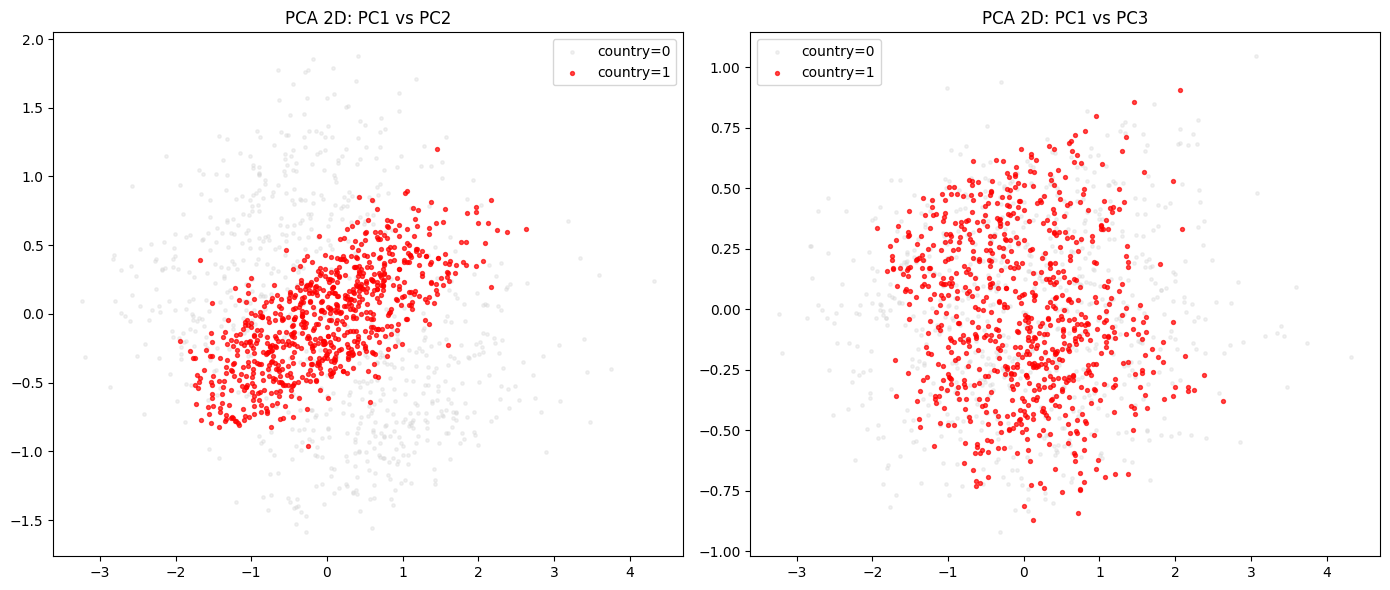

In [3]:
import json
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from sentence_transformers import SentenceTransformer
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# --- Model ---
class Head(nn.Module):
    def __init__(self):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(384, 64), nn.ReLU(),
            nn.Linear(64, 64),  nn.ReLU(),
            nn.Linear(64, 64),  nn.ReLU(),   # layer L
            nn.Linear(64, 64),  nn.ReLU(),
            nn.Linear(64, 8),
        )
    def forward(self, x):
        return self.layers(x)

enc = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2")
m = Head()
m.load_state_dict(torch.load("model.pt", map_location="cpu", weights_only=False))
m.eval()

with open("feature_names.json") as f:
    feature_names = json.load(f)
COUNTRY_IDX = feature_names.index("country")

def load_jsonl(path):
    texts, labels = [], []
    with open(path) as f:
        for line in f:
            r = json.loads(line)
            texts.append(r["text"]); labels.append(r["labels"])
    return texts, np.array(labels)

train_texts, y_train = load_jsonl("data/train.jsonl")
test_texts,  y_test  = load_jsonl("data/test.jsonl")

def get_acts(texts, batch=128):
    out = []
    for i in range(0, len(texts), batch):
        emb = torch.from_numpy(enc.encode(texts[i:i+batch], convert_to_numpy=True))
        with torch.no_grad():
            out.append(m.layers[:6](emb).numpy())
    return np.concatenate(out, axis=0)

print("Encoding...")
X_train = get_acts(train_texts)
X_test  = get_acts(test_texts)
y_train_c = y_train[:, COUNTRY_IDX]
y_test_c  = y_test[:, COUNTRY_IDX]

pos = X_test[y_test_c == 1]
neg = X_test[y_test_c == 0]
print(f"  positives: {len(pos)}, negatives: {len(neg)}")

# =====================================================================
# DIAGNOSTIC 1: Norm / magnitude
# =====================================================================
print("\n=== Norm comparison ===")
print(f"  ||x|| positives: mean={np.linalg.norm(pos,axis=1).mean():.3f}  std={np.linalg.norm(pos,axis=1).std():.3f}")
print(f"  ||x|| negatives: mean={np.linalg.norm(neg,axis=1).mean():.3f}  std={np.linalg.norm(neg,axis=1).std():.3f}")

# =====================================================================
# DIAGNOSTIC 2: PCA to 2D and 3D, visualize
# =====================================================================
print("\n=== PCA ===")
pca = PCA(n_components=10).fit(X_train)
print(f"  explained variance ratio (first 10): {np.round(pca.explained_variance_ratio_,3)}")

X_test_2d = pca.transform(X_test)[:, :2]
X_test_3d = pca.transform(X_test)[:, :3]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].scatter(X_test_2d[y_test_c==0,0], X_test_2d[y_test_c==0,1], s=6, alpha=0.3, label="country=0", c="lightgray")
axes[0].scatter(X_test_2d[y_test_c==1,0], X_test_2d[y_test_c==1,1], s=8, alpha=0.7, label="country=1", c="red")
axes[0].set_title("PCA 2D: PC1 vs PC2")
axes[0].legend()

axes[1].scatter(X_test_2d[y_test_c==0,0], pca.transform(X_test)[y_test_c==0,2], s=6, alpha=0.3, label="country=0", c="lightgray")
axes[1].scatter(X_test_2d[y_test_c==1,0], pca.transform(X_test)[y_test_c==1,2], s=8, alpha=0.7, label="country=1", c="red")
axes[1].set_title("PCA 2D: PC1 vs PC3")
axes[1].legend()
plt.tight_layout()
plt.savefig("country_pca.png", dpi=120)
print("  saved country_pca.png")

# =====================================================================
# DIAGNOSTIC 3: Are positives multi-cluster?
# Cluster positives with KMeans for k=2..8, look at inertia drop and
# check if each cluster is linearly separable from the negatives.
# =====================================================================
print("\n=== KMeans on positives ===")
inertias = []
for k in range(1, 9):
    km = KMeans(n_clusters=k, n_init=10, random_state=0).fit(pos)
    inertias.append(km.inertia_)
    print(f"  k={k}  inertia={km.inertia_:.2f}")

# =====================================================================
# DIAGNOSTIC 4: Per-cluster linear separability
# Take k=4 clusters of positives; for each cluster, train a linear probe
# (cluster vs all negatives) and report accuracy.
# =====================================================================
print("\n=== Per-cluster linear separability (k=4 on positives) ===")
K = 4
km = KMeans(n_clusters=K, n_init=10, random_state=0).fit(X_train[y_train_c==1])
train_pos = X_train[y_train_c==1]
train_neg = X_train[y_train_c==0]
test_pos  = X_test[y_test_c==1]
test_neg  = X_test[y_test_c==0]

train_cluster = km.predict(train_pos)
test_cluster  = km.predict(test_pos)

for c in range(K):
    Xtr = np.concatenate([train_pos[train_cluster==c], train_neg], axis=0)
    ytr = np.concatenate([np.ones((train_cluster==c).sum()), np.zeros(len(train_neg))])
    Xte = np.concatenate([test_pos[test_cluster==c], test_neg], axis=0)
    yte = np.concatenate([np.ones((test_cluster==c).sum()), np.zeros(len(test_neg))])
    clf = LogisticRegression(max_iter=2000).fit(Xtr, ytr)
    acc = accuracy_score(yte, clf.predict(Xte))
    print(f"  cluster {c} (n_train={(train_cluster==c).sum()}):  linear acc vs negatives = {acc:.3f}")

# =====================================================================
# DIAGNOSTIC 5: Cosine geometry — do positives spread in many directions?
# Compare mean cosine similarity within positives vs within negatives.
# =====================================================================
def mean_pairwise_cos(X, n=500, rng=None):
    rng = rng or np.random.default_rng(0)
    idx = rng.choice(len(X), size=min(n, len(X)), replace=False)
    A = X[idx]
    A = A / (np.linalg.norm(A, axis=1, keepdims=True) + 1e-9)
    S = A @ A.T
    iu = np.triu_indices_from(S, k=1)
    return S[iu].mean(), S[iu].std()

mp, sp = mean_pairwise_cos(pos)
mn, sn = mean_pairwise_cos(neg)
print("\n=== Pairwise cosine within class ===")
print(f"  positives: mean cos = {mp:.3f}  std = {sp:.3f}")
print(f"  negatives: mean cos = {mn:.3f}  std = {sn:.3f}")

## Task 3: Train a model with an even weirder representation

*Open ended.* Train your own model that encodes that feature (or some other feature) in a more interesting way than ours. "More interesting" is up to you to define and defend.

## What you'll submit

A single google doc, documenting what you tried, what worked, what didn't, and what structure emerged in the trained model. We'll happily read about your failures if the path to them was thoughtful.